# Spectral methods comparison

## tl;dr

- FFT, Morlet, Superlet, and STFT are applied to the same deterministic synthetic signal and the same canonical `exec` and `patt` blocks.
- All methods use the exact 2-40 Hz, 1 Hz output grid and 125 Hz analysis rate.
- FFT/STFT store PSD; Morlet/Superlet store wavelet power. Native amplitudes are shown only in method-specific panels.
- Shared maps and marginals use explicitly labelled per-method peak normalization for display only.
- Synthetic frequencies and burst intervals are validated before any real-data visualization is interpreted.

## Scope and comparison contract

This notebook validates spectral preprocessing checkpoint 8. It compares transform geometry, localization, output shape, runtime, and storage behavior. It does not compare subjects or recording families statistically, define an ML split, or claim that one transform is universally superior.

For real data, every method receives channel `Fp1` from canonical key `(1, 1, 1)`. Visual comparisons use the common 2-14 s interval. Runtime is measured by direct single-channel transforms so cache I/O is excluded; artifact size and full 63-channel output shape are read separately through each dataset wrapper.

In [1]:
import os
import sys
from pathlib import Path
from time import perf_counter

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-eeg-spectral-comparison")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not find project root")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from preprocessors import (
    compute_fft_psd,
    compute_morlet_power,
    compute_stft_psd,
    compute_superlet_power,
    load_preprocessing_config,
)
from utils.datasets import (
    FFTDataset,
    MorletDataset,
    NumpyDataset,
    STFTDataset,
    SuperletDataset,
)


METHODS = ("fft", "morlet", "superlet", "stft")
TRANSFORMS = {
    "fft": compute_fft_psd,
    "morlet": compute_morlet_power,
    "superlet": compute_superlet_power,
    "stft": compute_stft_psd,
}
DATASETS = {
    "fft": FFTDataset,
    "morlet": MorletDataset,
    "superlet": SuperletDataset,
    "stft": STFTDataset,
}
CONFIGS = {method: load_preprocessing_config(method) for method in METHODS}
COLORS = {
    "fft": "#4C78A8",
    "morlet": "#F58518",
    "superlet": "#54A24B",
    "stft": "#E45756",
}


def timed_transform(method: str, eeg: np.ndarray, source_sfreq: float):
    started = perf_counter()
    result = TRANSFORMS[method](
        eeg,
        source_sfreq=source_sfreq,
        config=CONFIGS[method],
    )
    return result, perf_counter() - started


def relative_db(power: np.ndarray, floor_db: float = -40.0) -> np.ndarray:
    peak = float(np.max(power))
    if not np.isfinite(peak) or peak <= 0:
        raise ValueError("Display normalization requires positive finite power")
    display = 10.0 * np.log10(np.maximum(power / peak, np.finfo(np.float32).tiny))
    return np.maximum(display, floor_db)


def peak_normalize(values: np.ndarray) -> np.ndarray:
    peak = float(np.max(values))
    if not np.isfinite(peak) or peak <= 0:
        raise ValueError("Display normalization requires positive finite values")
    return values / peak


pd.DataFrame(
    [
        {
            "method": method,
            "analysis_sfreq_hz": config.analysis_sfreq,
            "frequency_range_hz": f"{config.f_min:g}-{config.f_max:g}",
            "frequency_step_hz": config.frequency_step,
            "scaling": config.scaling,
            "dtype": config.dtype,
        }
        for method, config in CONFIGS.items()
    ]
).set_index("method")

,analysis_sfreq_hz,frequency_range_hz,frequency_step_hz,scaling,dtype
method,,,,,
fft,125.0,2-40,1.0,psd,float32
morlet,125.0,2-40,1.0,wavelet_power,float32
superlet,125.0,2-40,1.0,wavelet_power,float32
stft,125.0,2-40,1.0,psd,float32


## Synthetic comparison

The common 10 s signal contains a 10 Hz burst from 2-4 s and a 25 Hz burst from 6-8 s. FFT must recover both global spectral peaks. Morlet, Superlet, and STFT must recover each generating frequency at its burst center and place the peak time inside the generating interval.

In [2]:
def burst(
    time: np.ndarray,
    *,
    frequency: float,
    start: float,
    stop: float,
) -> np.ndarray:
    mask = (time >= start) & (time < stop)
    envelope = np.zeros_like(time)
    envelope[mask] = np.hanning(mask.sum())
    return envelope * np.sin(2.0 * np.pi * frequency * time)


source_sfreq = 1_000.0
source_time = np.arange(10_000, dtype=np.float64) / source_sfreq
synthetic_eeg = (
    burst(source_time, frequency=10.0, start=2.0, stop=4.0)
    + burst(source_time, frequency=25.0, start=6.0, stop=8.0)
)[np.newaxis, :]
expected_bursts = ((10.0, 2.0, 4.0), (25.0, 6.0, 8.0))

synthetic_results = {}
synthetic_rows = []
for method in METHODS:
    result, runtime_seconds = timed_transform(method, synthetic_eeg, source_sfreq)
    synthetic_results[method] = result
    assert np.array_equal(result.frequencies, np.arange(2.0, 41.0, dtype=np.float32))
    assert np.isfinite(result.eeg_power).all()
    assert np.all(result.eeg_power >= 0)
    synthetic_rows.append(
        {
            "method": method,
            "scaling": result.scaling,
            "output_shape": result.eeg_power.shape,
            "runtime_ms": 1_000.0 * runtime_seconds,
            "frequency_step_hz": float(np.diff(result.frequencies)[0]),
            "time_step_s": (
                np.nan if result.times is None else float(np.diff(result.times)[0])
            ),
            "native_min": float(result.eeg_power.min()),
            "native_max": float(result.eeg_power.max()),
        }
    )

fft_result = synthetic_results["fft"]
fft_top_two = set(
    fft_result.frequencies[np.argsort(fft_result.eeg_power[0])[-2:]].tolist()
)
assert fft_top_two == {10.0, 25.0}

localization_rows = []
for method in ("morlet", "superlet", "stft"):
    result = synthetic_results[method]
    assert result.times is not None
    for frequency, start, stop in expected_bursts:
        frequency_index = int(np.searchsorted(result.frequencies, frequency))
        peak_time = float(result.times[np.argmax(result.eeg_power[0, frequency_index])])
        center_time = (start + stop) / 2.0
        center_index = int(np.argmin(np.abs(result.times - center_time)))
        peak_frequency = float(
            result.frequencies[np.argmax(result.eeg_power[0, :, center_index])]
        )
        assert start <= peak_time <= stop
        assert peak_frequency == frequency
        localization_rows.append(
            {
                "method": method,
                "expected_frequency_hz": frequency,
                "expected_interval_s": f"{start:g}-{stop:g}",
                "peak_time_s": peak_time,
                "peak_frequency_at_center_hz": peak_frequency,
            }
        )

synthetic_summary = pd.DataFrame(synthetic_rows).set_index("method")
display(synthetic_summary)
display(pd.DataFrame(localization_rows).set_index(["method", "expected_frequency_hz"]))

,scaling,output_shape,runtime_ms,frequency_step_hz,time_step_s,native_min,native_max
method,,,,,,,
fft,psd,"(1, 39)",0.727190,1.0,NaN,4.335929e-12,0.039162
morlet,wavelet_power,"(1, 39, 29)",2.715301,1.0,0.256,2.418311e-33,16.454609
superlet,wavelet_power,"(1, 39, 26)",26.998358,1.0,0.256,5.071707e-35,0.177453
stft,psd,"(1, 39, 32)",1.762684,1.0,0.256,1.060224e-18,0.266636


expected_interval_s  peak_time_s  \
method   expected_frequency_hz                                    
morlet   10.0                                  2-4        2.948   
         25.0                                  6-8        7.044   
superlet 10.0                                  2-4        3.076   
         25.0                                  6-8        6.916   
stft     10.0                                  2-4        3.072   
         25.0                                  6-8        6.912   

                                peak_frequency_at_center_hz  
method   expected_frequency_hz                               
morlet   10.0                                          10.0  
         25.0                                          25.0  
superlet 10.0                                          10.0  
         25.0                                          25.0  
stft     10.0                                          10.0  
         25.0                                          25.0

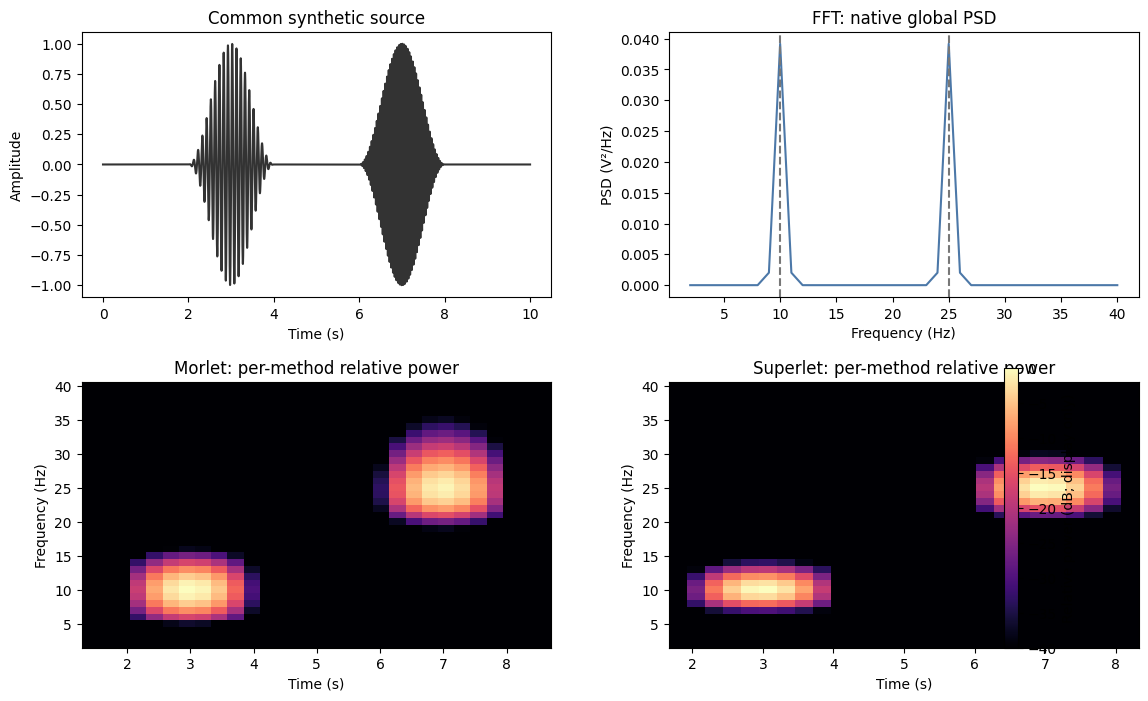

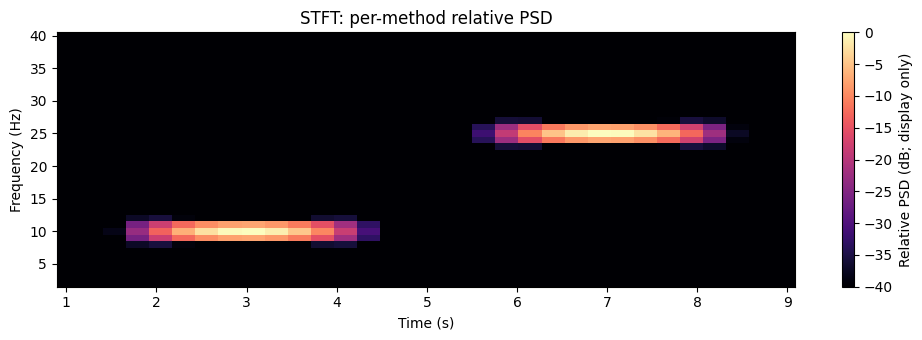

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(source_time, synthetic_eeg[0], color="#333333")
axes[0, 0].set(
    xlabel="Time (s)",
    ylabel="Amplitude",
    title="Common synthetic source",
)
axes[0, 1].plot(
    fft_result.frequencies,
    fft_result.eeg_power[0],
    color=COLORS["fft"],
)
axes[0, 1].axvline(10.0, color="#777777", linestyle="--")
axes[0, 1].axvline(25.0, color="#777777", linestyle="--")
axes[0, 1].set(
    xlabel="Frequency (Hz)",
    ylabel="PSD (V²/Hz)",
    title="FFT: native global PSD",
)
for axis, method in zip(axes[1], ("morlet", "superlet"), strict=True):
    result = synthetic_results[method]
    mesh = axis.pcolormesh(
        result.times,
        result.frequencies,
        relative_db(result.eeg_power[0]),
        shading="auto",
        cmap="magma",
        vmin=-40.0,
        vmax=0.0,
    )
    axis.set(
        xlabel="Time (s)",
        ylabel="Frequency (Hz)",
        title=f"{method.title()}: per-method relative power",
    )
fig.colorbar(mesh, ax=axes[1].tolist(), label="Relative power (dB; display only)")
fig.subplots_adjust(hspace=0.32, wspace=0.25, right=0.88)

stft_result = synthetic_results["stft"]
fig, axis = plt.subplots(figsize=(10, 3.5))
mesh = axis.pcolormesh(
    stft_result.times,
    stft_result.frequencies,
    relative_db(stft_result.eeg_power[0]),
    shading="auto",
    cmap="magma",
    vmin=-40.0,
    vmax=0.0,
)
axis.set(
    xlabel="Time (s)",
    ylabel="Frequency (Hz)",
    title="STFT: per-method relative PSD",
)
fig.colorbar(mesh, ax=axis, label="Relative PSD (dB; display only)")
fig.tight_layout()

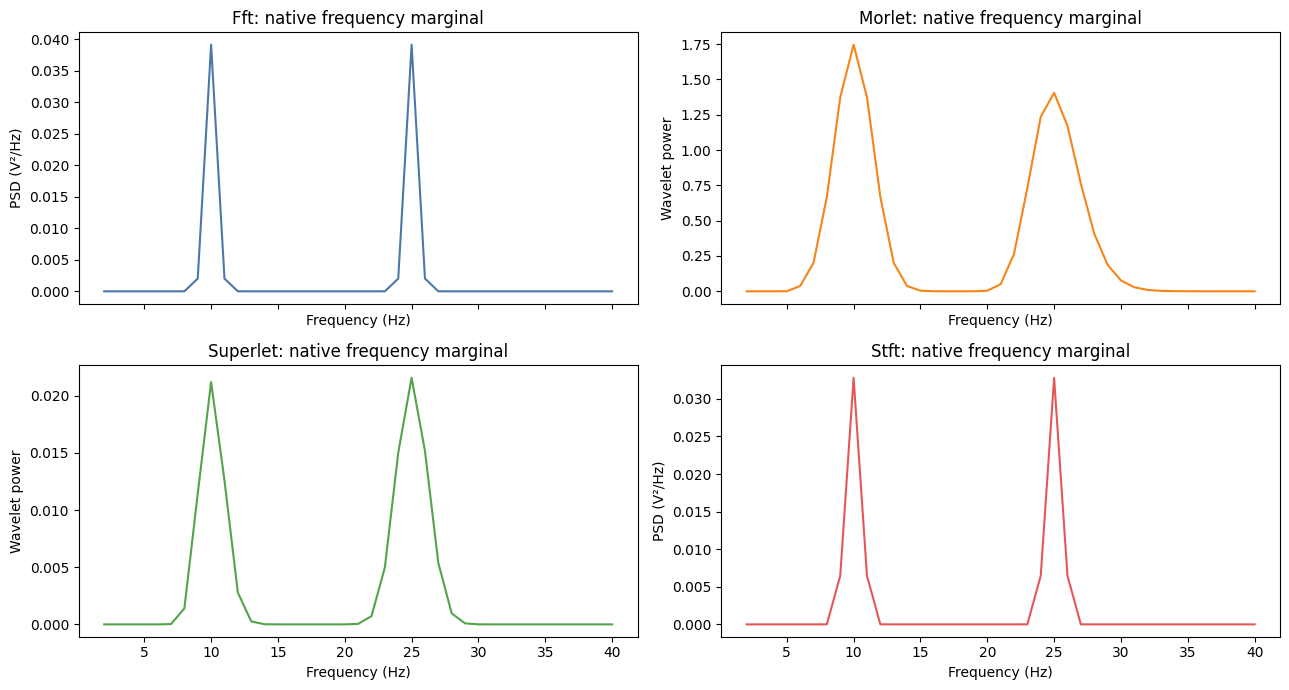

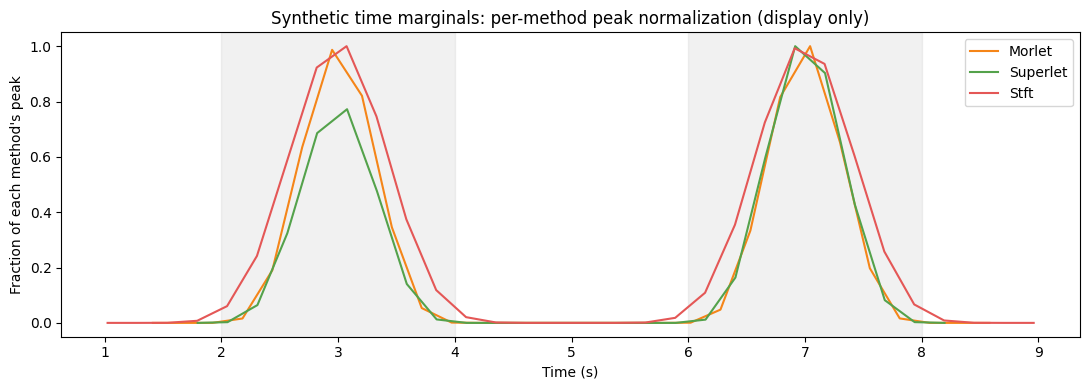

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for axis, method in zip(axes.flat, METHODS, strict=True):
    result = synthetic_results[method]
    marginal = (
        result.eeg_power[0]
        if result.times is None
        else result.eeg_power[0].mean(axis=1)
    )
    unit = "PSD (V²/Hz)" if result.scaling == "psd" else "Wavelet power"
    axis.plot(result.frequencies, marginal, color=COLORS[method])
    axis.set(
        xlabel="Frequency (Hz)",
        ylabel=unit,
        title=f"{method.title()}: native frequency marginal",
    )
fig.tight_layout()

fig, axis = plt.subplots(figsize=(11, 4))
for method in ("morlet", "superlet", "stft"):
    result = synthetic_results[method]
    time_marginal = result.eeg_power[0].mean(axis=0)
    axis.plot(
        result.times,
        peak_normalize(time_marginal),
        color=COLORS[method],
        label=method.title(),
    )
axis.axvspan(2.0, 4.0, color="#BBBBBB", alpha=0.2)
axis.axvspan(6.0, 8.0, color="#BBBBBB", alpha=0.2)
axis.set(
    xlabel="Time (s)",
    ylabel="Fraction of each method's peak",
    title="Synthetic time marginals: per-method peak normalization (display only)",
)
axis.legend()
fig.tight_layout()

## Canonical real-block comparison

The source signal is loaded once per recording family. Direct transforms use only `Fp1` to make runtime comparisons independent of cache I/O and channel count. Full cached dataset outputs are then loaded to verify the production shape and artifact size. The common display interval is 2-14 s for every method and both recording families.

In [5]:
dataset_specs = {
    "exec": {
        "dataset_dir": PROJECT_ROOT / "data" / "Data_Train",
        "dataset_step_type": "exec",
    },
    "patt": {
        "dataset_dir": PROJECT_ROOT / "data" / "Data_Pattern",
        "dataset_step_type": "patt",
    },
}
common_start = 2.0
common_stop = 14.0
channel_name = "Fp1"

real_sources = {}
real_results = {}
real_rows = []
for family, spec in dataset_specs.items():
    source_dataset = NumpyDataset(**spec)
    source = source_dataset[0]
    channel_index = source.eeg_channels.index(channel_name)
    channel_eeg = source.eeg[channel_index : channel_index + 1]
    real_sources[family] = source
    real_results[family] = {}

    for method in METHODS:
        result, runtime_seconds = timed_transform(method, channel_eeg, source.sfreq)
        real_results[family][method] = result
        dataset = DATASETS[method](**spec)
        cached_sample = dataset[0]
        entry_dir = dataset.get_cache_entry_path(0)
        artifact_bytes = sum(
            path.stat().st_size for path in entry_dir.iterdir() if path.is_file()
        )

        assert cached_sample.sample.subject_id == source.sample.subject_id
        assert cached_sample.sample.trial_number == source.sample.trial_number
        assert cached_sample.sample.block_index == source.sample.block_index
        assert cached_sample.eeg_channels[channel_index] == channel_name
        assert cached_sample.eeg_power.shape[0] == 63
        assert cached_sample.eeg_power.shape[1] == 39
        if result.times is not None:
            assert result.times[0] <= common_start
            assert result.times[-1] >= common_stop

        real_rows.append(
            {
                "family": family,
                "method": method,
                "scaling": result.scaling,
                "single_channel_runtime_ms": 1_000.0 * runtime_seconds,
                "full_output_shape": cached_sample.eeg_power.shape,
                "frequency_step_hz": float(np.diff(result.frequencies)[0]),
                "time_step_s": (
                    np.nan if result.times is None else float(np.diff(result.times)[0])
                ),
                "artifact_kib": artifact_bytes / 1024.0,
                "native_min_fp1": float(result.eeg_power.min()),
                "native_max_fp1": float(result.eeg_power.max()),
            }
        )

real_summary = pd.DataFrame(real_rows).set_index(["family", "method"])
display(real_summary)

scaling  single_channel_runtime_ms full_output_shape  \
family method                                                                 
exec   fft                 psd                   0.833352          (63, 39)   
       morlet    wavelet_power                   3.148731      (63, 39, 53)   
       superlet  wavelet_power                  35.723797      (63, 39, 50)   
       stft                psd                   2.038034      (63, 39, 55)   
patt   fft                 psd                   1.054384          (63, 39)   
       morlet    wavelet_power                   4.206155      (63, 39, 92)   
       superlet  wavelet_power                  53.289943      (63, 39, 89)   
       stft                psd                   2.498630      (63, 39, 94)   

                 frequency_step_hz  time_step_s  artifact_kib  native_min_fp1  \
family method                                                                   
exec   fft                     1.0          NaN     12.000000        0.000058   
       morlet                  1.0        0.256    511.621094        0.000262   
       superlet                1.0        0.256    482.776367        0.000003   
       stft                    1.0        0.256    530.766602        0.000003   
patt   fft                     1.0          NaN     12.003906        0.000074   
       morlet                  1.0        0.256    886.085938        0.000870   
       superlet                1.0        0.256    857.241211        0.000003   
       stft                    1.0        0.256    905.231445        0.000002   

                 native_max_fp1  
family method                    
exec   fft             0.000704  
       morlet          1.280437  
       superlet        0.002447  
       stft            0.006120  
patt   fft             0.000401  
       morlet          1.930218  
       superlet        0.004342  
       stft            0.010131

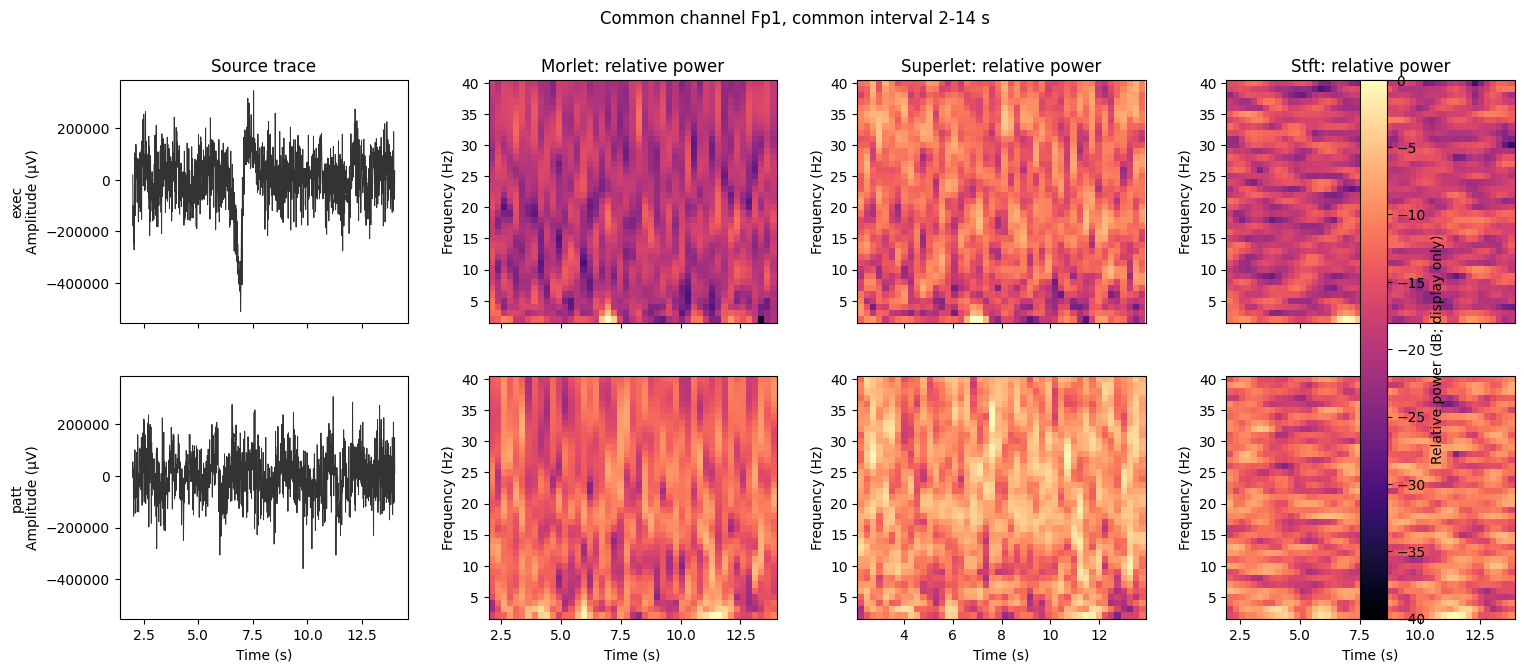

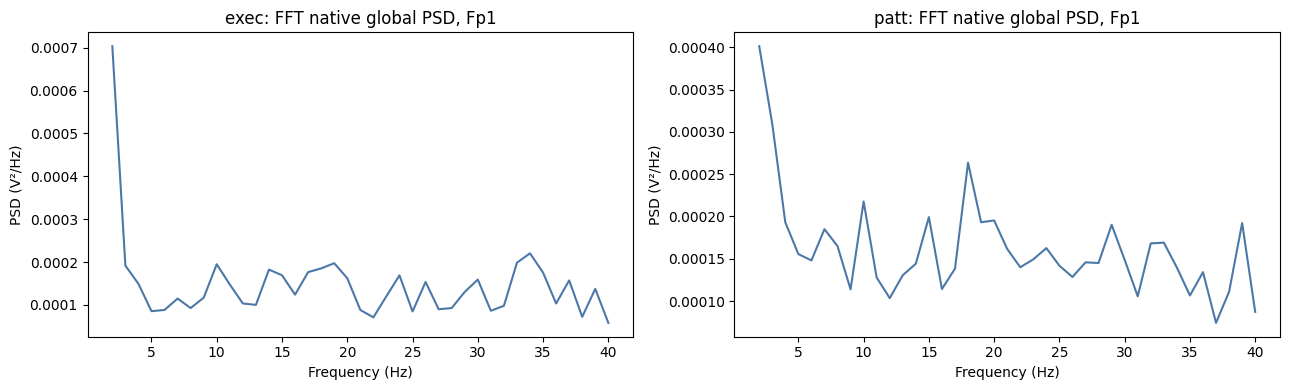

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex="col", sharey="col")
for row, family in enumerate(("exec", "patt")):
    source = real_sources[family]
    source_time = np.arange(source.eeg.shape[1], dtype=np.float64) / source.sfreq
    source_mask = (source_time >= common_start) & (source_time <= common_stop)
    channel_index = source.eeg_channels.index(channel_name)
    axes[row, 0].plot(
        source_time[source_mask],
        source.eeg[channel_index, source_mask] * 1e6,
        color="#333333",
        linewidth=0.7,
    )
    axes[row, 0].set(
        ylabel=f"{family}\nAmplitude (µV)",
        title="Source trace" if row == 0 else None,
    )

    for column, method in enumerate(("morlet", "superlet", "stft"), start=1):
        result = real_results[family][method]
        time_mask = (result.times >= common_start) & (result.times <= common_stop)
        mesh = axes[row, column].pcolormesh(
            result.times[time_mask],
            result.frequencies,
            relative_db(result.eeg_power[0][:, time_mask]),
            shading="auto",
            cmap="magma",
            vmin=-40.0,
            vmax=0.0,
        )
        axes[row, column].set(
            ylabel="Frequency (Hz)",
            title=(f"{method.title()}: relative power" if row == 0 else None),
        )

for axis in axes[-1]:
    axis.set_xlabel("Time (s)")
fig.colorbar(mesh, ax=axes[:, 1:].ravel().tolist(), label="Relative power (dB; display only)")
fig.suptitle(f"Common channel {channel_name}, common interval {common_start:g}-{common_stop:g} s")
fig.subplots_adjust(top=0.88, right=0.9, wspace=0.28, hspace=0.22)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
for axis, family in zip(axes, ("exec", "patt"), strict=True):
    result = real_results[family]["fft"]
    axis.plot(result.frequencies, result.eeg_power[0], color=COLORS["fft"])
    axis.set(
        xlabel="Frequency (Hz)",
        ylabel="PSD (V²/Hz)",
        title=f"{family}: FFT native global PSD, {channel_name}",
    )
fig.tight_layout()

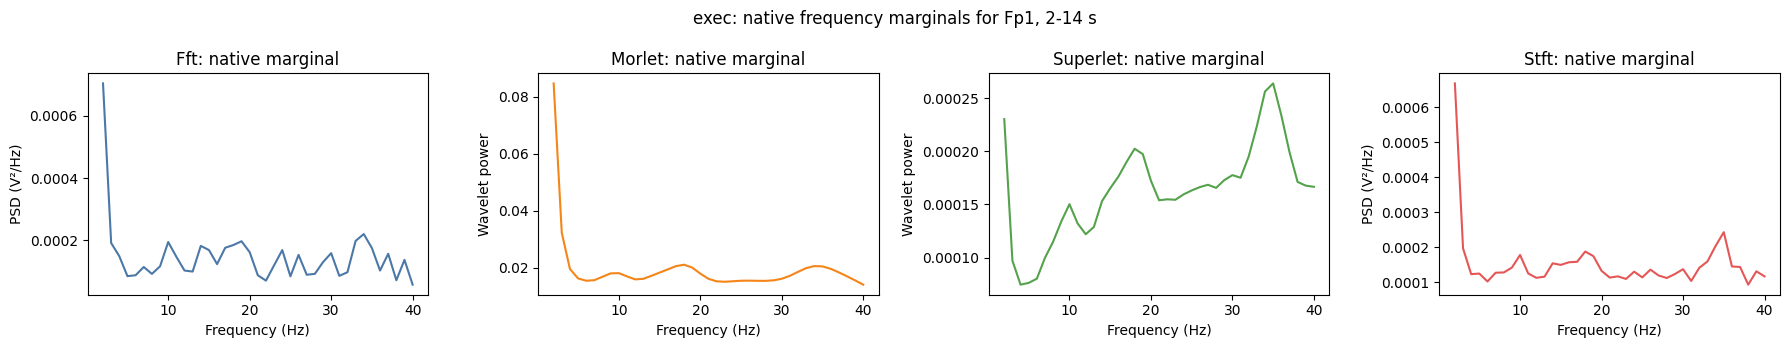

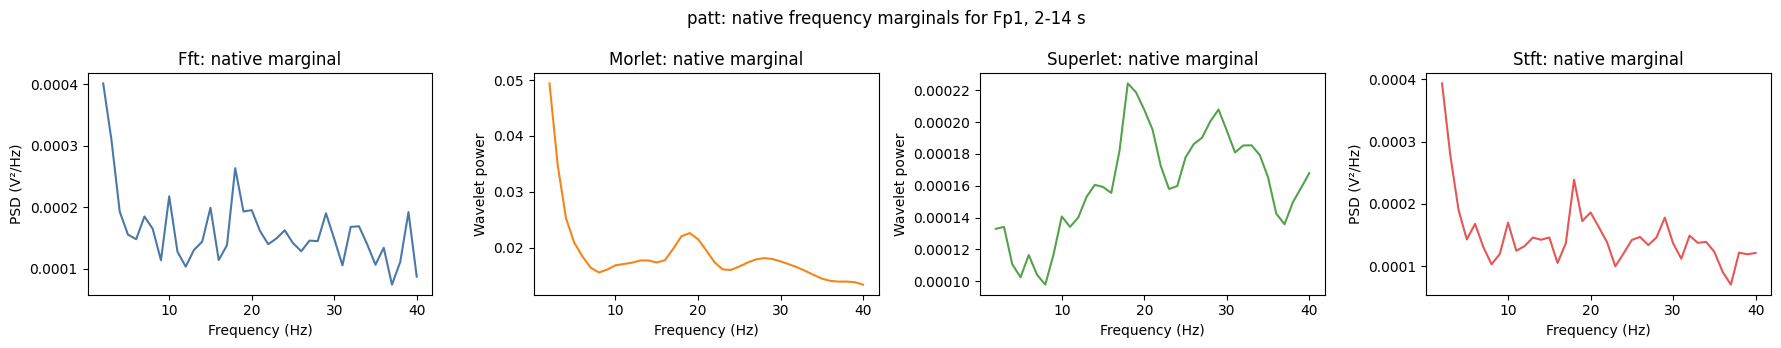

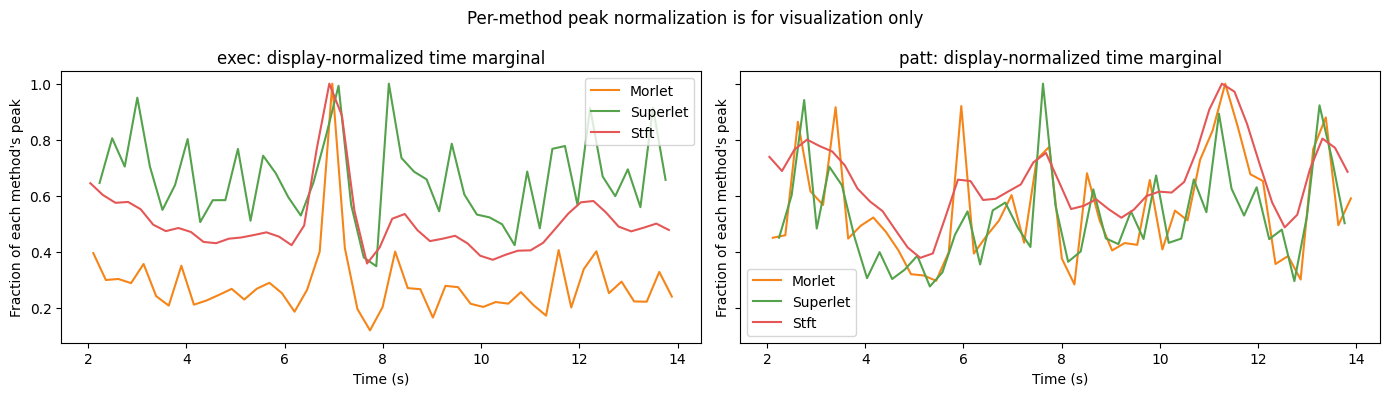

In [7]:
for family in ("exec", "patt"):
    fig, axes = plt.subplots(1, 4, figsize=(18, 3.5), sharex=True)
    for axis, method in zip(axes, METHODS, strict=True):
        result = real_results[family][method]
        if result.times is None:
            marginal = result.eeg_power[0]
        else:
            time_mask = (result.times >= common_start) & (result.times <= common_stop)
            marginal = result.eeg_power[0][:, time_mask].mean(axis=1)
        unit = "PSD (V²/Hz)" if result.scaling == "psd" else "Wavelet power"
        axis.plot(result.frequencies, marginal, color=COLORS[method])
        axis.set(
            xlabel="Frequency (Hz)",
            ylabel=unit,
            title=f"{method.title()}: native marginal",
        )
    fig.suptitle(f"{family}: native frequency marginals for {channel_name}, {common_start:g}-{common_stop:g} s")
    fig.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for axis, family in zip(axes, ("exec", "patt"), strict=True):
    for method in ("morlet", "superlet", "stft"):
        result = real_results[family][method]
        time_mask = (result.times >= common_start) & (result.times <= common_stop)
        time_marginal = result.eeg_power[0][:, time_mask].mean(axis=0)
        axis.plot(
            result.times[time_mask],
            peak_normalize(time_marginal),
            color=COLORS[method],
            label=method.title(),
        )
    axis.set(
        xlabel="Time (s)",
        ylabel="Fraction of each method's peak",
        title=f"{family}: display-normalized time marginal",
    )
    axis.legend()
fig.suptitle("Per-method peak normalization is for visualization only")
fig.tight_layout()

## Conclusions

- All four methods return the exact shared 2-40 Hz, 1 Hz grid and preserve their documented scaling contracts.
- The deterministic synthetic signal passes global FFT peak checks and time-frequency localization checks for Morlet, Superlet, and STFT.
- FFT has no time axis. The three time-frequency methods share a 0.256 s output step but retain different valid time supports because their edge contracts differ.
- Native amplitude comparisons are meaningful only within the same scaling family and method configuration. Shared relative-dB maps and peak-normalized marginals above are presentation-only.
- The canonical real panels use the same key, source channel, and 2-14 s interval across methods. They demonstrate transform behavior and storage cost, not a statistical difference between `exec` and `patt`.
- Full outputs retain `(channel, frequency)` for FFT and `(channel, frequency, time)` for Morlet, Superlet, and STFT, with original EOG stored separately by the source dataset.